In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import interrupt, Command

from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field

from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate
from langchain.messages import RemoveMessage

from langgraph.graph import MessagesState

from dotenv import load_dotenv
from huggingface_hub import InferenceClient
import requests, operator, random, sqlite3

from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [5]:
load_dotenv()

True

In [6]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)
model = ChatHuggingFace(llm=llm)
MAX_TOKENS = 150

In [7]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

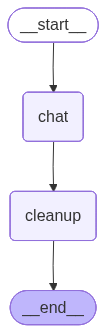

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", END)

graph = builder.compile(checkpointer=InMemorySaver())
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

In [12]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='b35826d8-7e91-4e48-94e5-7b4c3d682afb'),
  AIMessage(content="LangChain is a framework designed to help developers integrate and build upon a variety of language models and tools to create powerful applications. It provides a set of utilities and abstractions to simplify the process of working with large language models (LLMs) like Alibaba Cloud's LangGraph. LangChain aims to make it easier to develop and deploy applications that can handle complex natural language processing tasks.\n\n### Key Features and Components of LangChain\n\n1. **Modular Architecture**:\n   - **Data Processing**: LangChain includes tools for preprocessing and formatting input data to ensure it is suitable for the language model.\n   - **Model Inference**: It provides easy access to inference APIs for running predictions on language models.\n   - **Post-processing**: Tools for post-processing the model outputs 

In [13]:
stored_messages = graph.get_state(config)
print("Stored messages after cleanup:", len(stored_messages.values["messages"]))

Stored messages after cleanup: 8
